# 01 - HPC Job Energy and Emissions Prediction

Goal: estimate job energy consumption from features available in the HPC trace and convert it into emissions using a synthetic carbon-intensity signal in gCO2/kWh.

This notebook is a presentation-oriented view of the results. The reproducible computation lives in `scripts/01_run_carbon_prediction.py` and `src/hpc_carbon_scheduler/carbon_model.py`.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

PROJECT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS = PROJECT / 'results' / 'carbon_prediction'
sys.path.insert(0, str(PROJECT / 'src'))

print('Project:', PROJECT)
print('Results:', RESULTS)

Project: C:\Users\morne\Desktop\AI for industry\project_rebuild
Results: C:\Users\morne\Desktop\AI for industry\project_rebuild\results\carbon_prediction


## Result Generation

If the files in `results/carbon_prediction` do not exist yet, run this from the terminal:

```bash
python scripts/01_run_carbon_prediction.py --max-rows 60000
```

In [2]:
metrics = pd.read_csv(RESULTS / 'metrics.csv')
metrics.T.rename(columns={0: 'value'})

,value
rows_total,58846.000000
rows_train,44134.000000
rows_test,14712.000000
energy_mae_kwh,6.763108
energy_rmse_kwh,35.424432
energy_r2,0.492209
emissions_mae_kg,2.456361
emissions_rmse_kg,12.854255
emissions_r2,0.468336


## Interpretation

- `energy_mae_kwh` measures the average error of the energy estimate.
- `emissions_mae_kg` measures the average CO2 error using the synthetic carbon-intensity signal.
- The model uses only features available, or reasonably known, at job submission time: requested resources, time limit, and temporal features.
- It does not use actual runtime as an input feature, to avoid leakage.
- Metrics are computed only on the chronological test set; `job_predictions.csv` stores predictions for all valid jobs and includes the `split` column.

In [3]:
feature_importance = pd.read_csv(RESULTS / 'feature_importance.csv')
feature_importance

,feature,importance
0,time_limit,0.247884
1,num_tasks,0.226571
2,mem_req,0.119359
3,num_gpus_req,0.116509
4,hour,0.086884
5,weekday,0.055939
6,num_nodes_req,0.051902
7,cores_per_task,0.043770
8,num_cores_req,0.040569
9,month,0.010612


## Main Plots

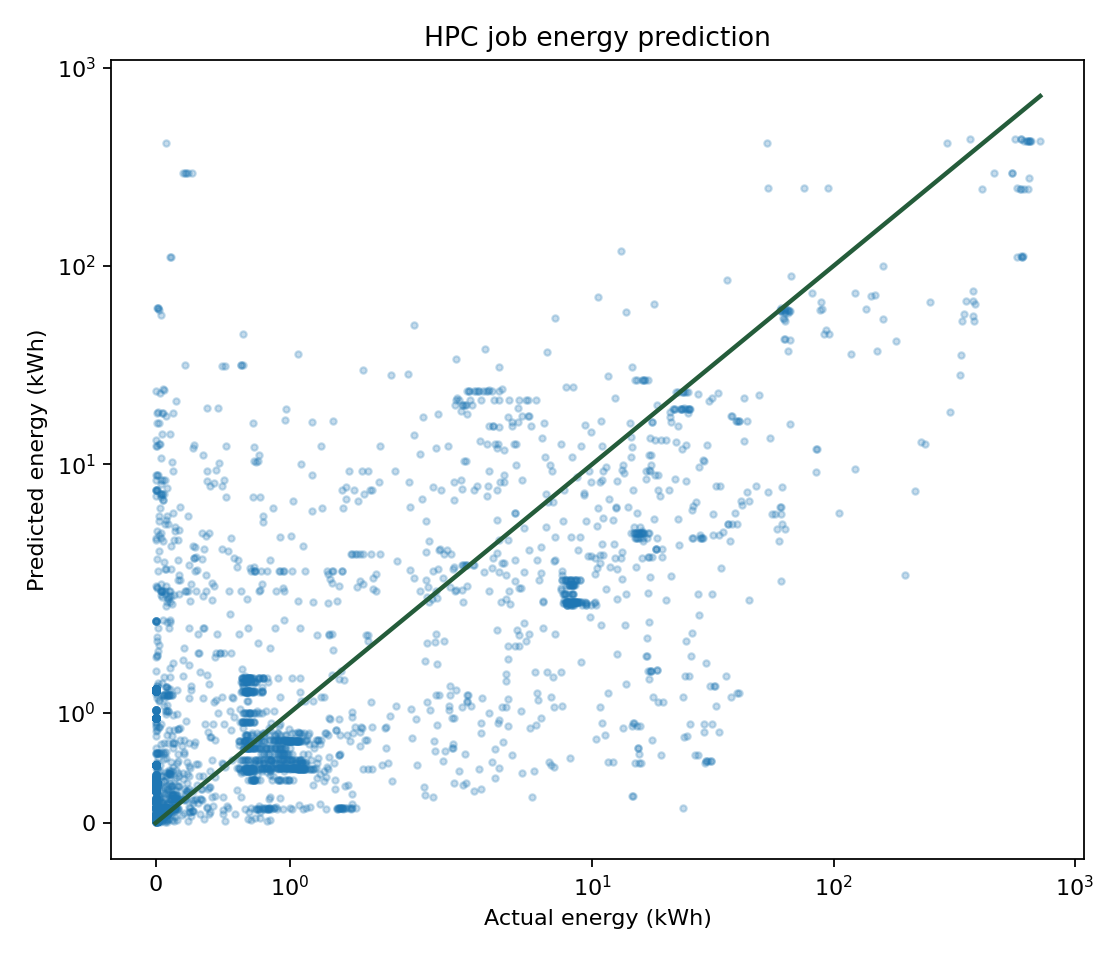

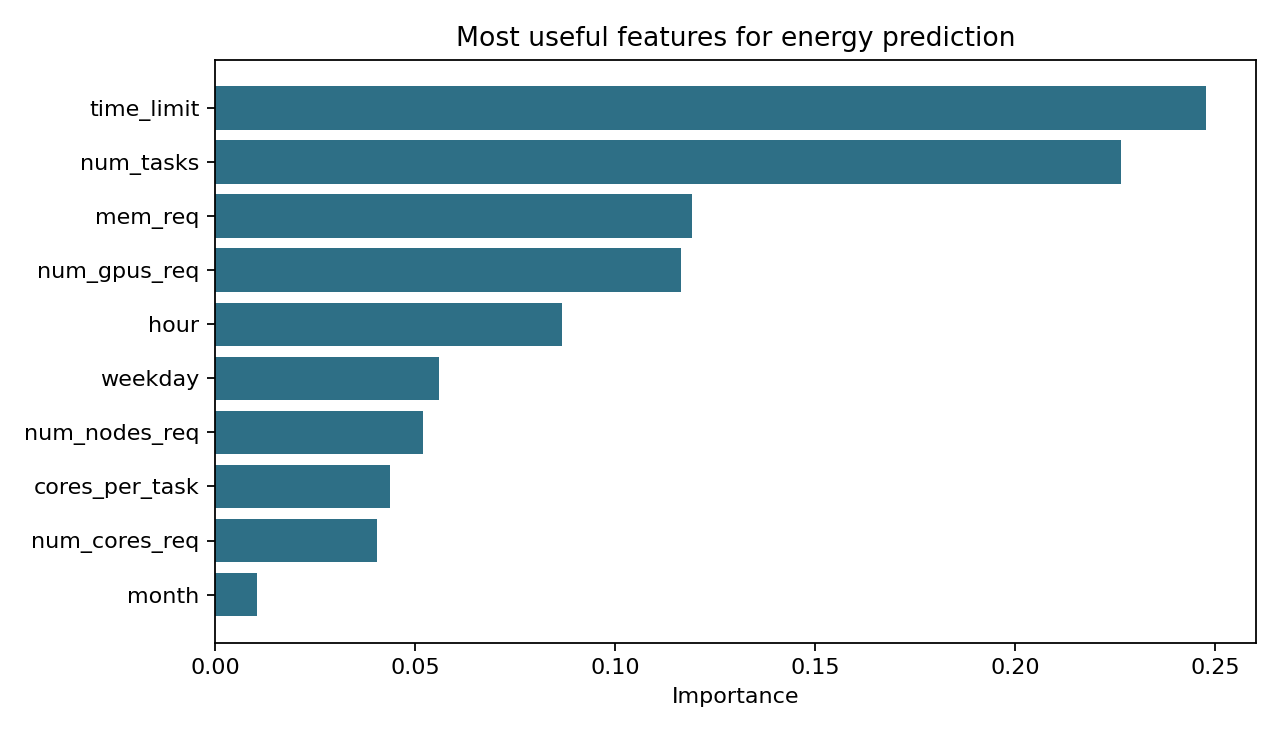

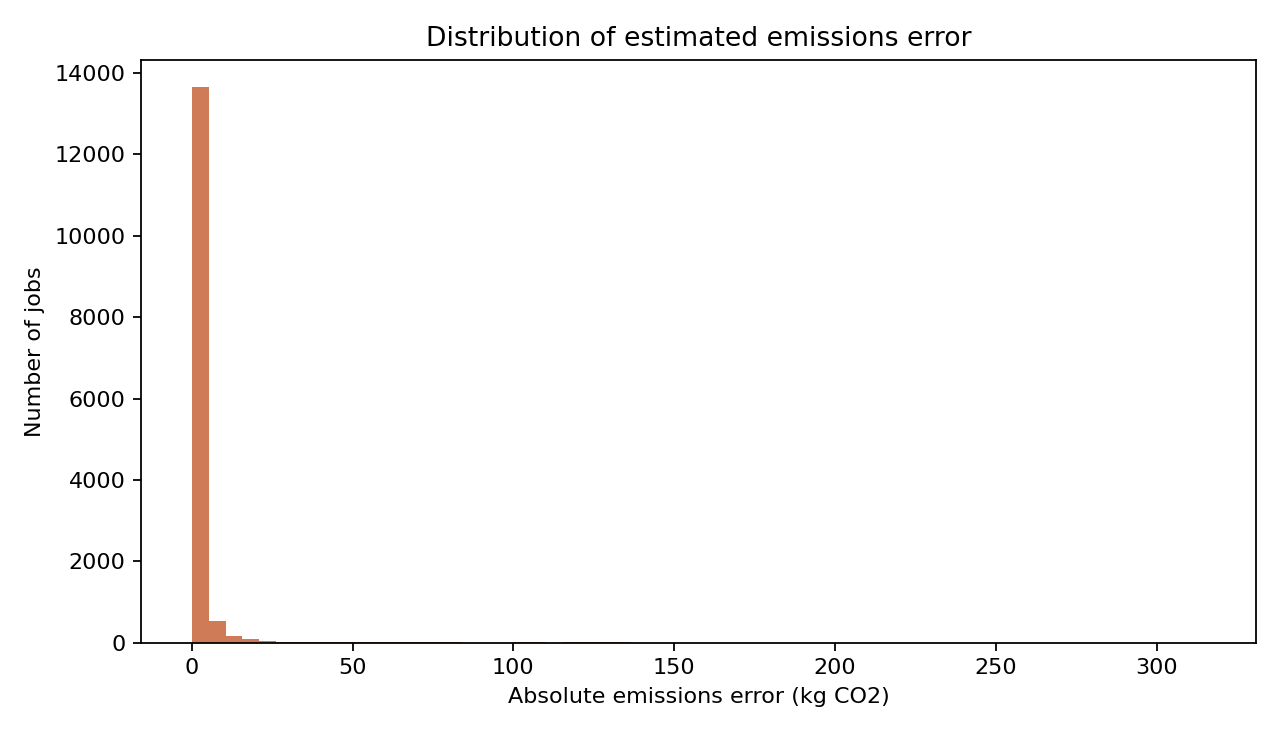

In [4]:
for name in ['energy_actual_vs_predicted.png', 'feature_importance.png', 'emissions_error_histogram.png']:
    display(Image(filename=str(RESULTS / name)))

## Prediction Examples

In [5]:
pred = pd.read_csv(RESULTS / 'job_predictions.csv')
print(pred['split'].value_counts().to_string())
cols = ['job_id', 'split', 'run_time', 'num_nodes_req', 'energy_kwh', 'pred_energy_kwh', 'emissions_kg', 'pred_emissions_kg']
pred[cols].head(15)

split
train    44134
test     14712


,job_id,split,run_time,num_nodes_req,energy_kwh,pred_energy_kwh,emissions_kg,pred_emissions_kg
0,5370710,train,13243,1,3.629351,8.430699,0.655082,1.521703
1,175694,train,19576,8,44.837986,10.949152,7.550412,1.843763
2,2214444,train,17052,13,40.172673,41.714246,7.703273,7.998876
3,2687047,train,19869,16,87.687426,11.171975,16.964455,2.161387
4,4281751,train,7342,9,15.271026,13.406773,2.667659,2.341997
5,584948,train,6749,4,5.185669,2.838374,0.936155,0.512404
6,3192383,train,12996,1,3.654979,0.808441,0.706864,0.156350
7,3783714,train,36027,13,81.527539,39.513204,15.441377,7.483830
8,3096661,train,8499,6,9.942273,3.202176,1.909868,0.615124
9,4678367,train,10703,1,2.251097,0.737939,0.415484,0.136201


## Key Message

This section shows that the supercomputer trace can be used to estimate energy consumption per job. That estimate then becomes the scheduler input: if predicted energy and carbon intensity are known, the scheduler can estimate the carbon cost of starting a job in a given time window.